# MNIST Adversarial Attacks with PyTorch

This notebook studies how small input perturbations can reduce the reliability of an image classifier. MNIST is used to compare ordinary random noise with gradient-based adversarial attacks.

The experiments cover:

- clean-image classification with feed-forward neural networks,
- random-noise robustness,
- gradients of the loss with respect to the input,
- Fast Gradient Sign Method (FGSM),
- targeted FGSM,
- Basic Iterative Method (BIM),
- targeted BIM,
- and attack-parameter variations involving different accuracy thresholds and target classes.


## Imports and Reproducibility


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: cuda


## Load and Prepare MNIST


In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32").reshape(len(X_train), -1) / 255.0
X_test = X_test.astype("float32").reshape(len(X_test), -1) / 255.0

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 784)
X_test: (10000, 784)
y_train: (60000,)
y_test: (10000,)


## Class-Wise Test Indices


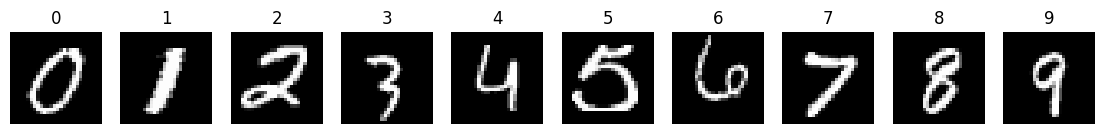

In [ ]:
sample = [[] for _ in range(10)]

for i, y in enumerate(y_test):
    sample[int(y)].append(i)

rng = np.random.default_rng(42)
random_sel = [
    sample[digit][rng.integers(0, len(sample[digit]))]
    for digit in range(10)
]

fig, ax = plt.subplots(1, 10, figsize=(14, 2))

for digit, index in enumerate(random_sel):
    ax[digit].imshow(
        X_test[index].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax[digit].set_title(str(digit))
    ax[digit].axis("off")

plt.show()


## Feed-Forward Classifier Architectures

Two architecture variants are retained because they represent distinct baseline designs explored in the source material: a one-hidden-layer network and a two-hidden-layer network.


In [ ]:
class FFNNOneHidden(nn.Module):
    def __init__(self, n_inputs=784, n_hidden=500, n_outputs=10):
        super().__init__()
        self.dense1 = nn.Linear(n_inputs, n_hidden)
        self.dense2 = nn.Linear(n_hidden, n_outputs)

    def forward(self, x):
        x = F.relu(self.dense1(x))
        return self.dense2(x)


class FFNNTwoHidden(nn.Module):
    def __init__(
        self,
        n_inputs=784,
        n_hidden1=500,
        n_hidden2=200,
        n_outputs=10,
    ):
        super().__init__()
        self.dense1 = nn.Linear(n_inputs, n_hidden1)
        self.dense2 = nn.Linear(n_hidden1, n_hidden2)
        self.dense3 = nn.Linear(n_hidden2, n_outputs)

    def forward(self, x):
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        return self.dense3(x)


## Training Utility


In [ ]:
def train_classifier(
    model,
    X_train_t,
    y_train_t,
    X_test_t,
    y_test_t,
    num_epochs=20,
    batch_size=500,
    learning_rate=1e-3,
):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    n_train = X_train_t.shape[0]
    history = {
        "accuracy": [],
        "loss": [],
        "val_accuracy": [],
        "val_loss": [],
    }

    start = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()

        permutation = torch.randperm(
            n_train,
            device=device,
        )

        epoch_loss = 0.0
        correct = 0

        for start_idx in range(0, n_train, batch_size):
            idx = permutation[start_idx:start_idx + batch_size]

            optimizer.zero_grad()

            logits = model(X_train_t[idx])
            loss = loss_function(
                logits,
                y_train_t[idx],
            )

            loss.backward()
            optimizer.step()

            epoch_loss += (
                loss.item()
                * len(idx)
            )

            correct += (
                logits.argmax(dim=1)
                == y_train_t[idx]
            ).sum().item()

        train_loss = epoch_loss / n_train
        train_acc = correct / n_train

        model.eval()

        with torch.no_grad():
            test_logits = model(X_test_t)
            test_loss = loss_function(
                test_logits,
                y_test_t,
            ).item()

            test_acc = (
                test_logits.argmax(dim=1)
                == y_test_t
            ).float().mean().item()

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(test_loss)
        history["val_accuracy"].append(test_acc)

        print(
            f"Epoch {epoch:2d}/{num_epochs}  "
            f"loss={train_loss:.6f}  "
            f"accuracy={train_acc:.4f}  "
            f"test_loss={test_loss:.6f}  "
            f"test_accuracy={test_acc:.4f}"
        )

    print(
        "Elapsed training time: "
        f"{time.time() - start:.2f} s"
    )

    return history


def plot_history(history):
    fig, ax = plt.subplots(
        1,
        2,
        figsize=(12, 4),
    )

    ax[0].plot(
        history["accuracy"],
        label="train",
    )
    ax[0].plot(
        history["val_accuracy"],
        label="test",
    )
    ax[0].set_title("Accuracy")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(
        history["loss"],
        label="train",
    )
    ax[1].plot(
        history["val_loss"],
        label="test",
    )
    ax[1].set_title("Loss")
    ax[1].grid(True)
    ax[1].legend()

    plt.show()


## Train the Primary Classifier

The one-hidden-layer network is used as the attack target in the remaining experiments.


Epoch  1/20  loss=0.501009  accuracy=0.8764  test_loss=0.243406  test_accuracy=0.9304
Epoch  2/20  loss=0.212510  accuracy=0.9398  test_loss=0.170284  test_accuracy=0.9514
Epoch  3/20  loss=0.151934  accuracy=0.9572  test_loss=0.134270  test_accuracy=0.9612
Epoch  4/20  loss=0.117739  accuracy=0.9666  test_loss=0.112069  test_accuracy=0.9663
Epoch  5/20  loss=0.095317  accuracy=0.9730  test_loss=0.099139  test_accuracy=0.9703
Epoch  6/20  loss=0.078966  accuracy=0.9780  test_loss=0.091395  test_accuracy=0.9727
Epoch  7/20  loss=0.065075  accuracy=0.9818  test_loss=0.081277  test_accuracy=0.9756
Epoch  8/20  loss=0.055687  accuracy=0.9844  test_loss=0.076342  test_accuracy=0.9766
Epoch  9/20  loss=0.046829  accuracy=0.9873  test_loss=0.073019  test_accuracy=0.9782
Epoch 10/20  loss=0.040168  accuracy=0.9891  test_loss=0.070915  test_accuracy=0.9778
Epoch 11/20  loss=0.034646  accuracy=0.9908  test_loss=0.069263  test_accuracy=0.9787
Epoch 12/20  loss=0.029376  accuracy=0.9929  test_loss

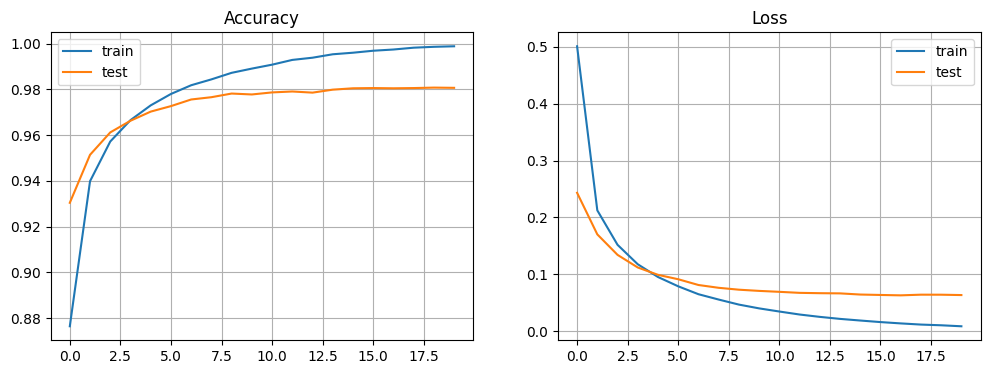

Clean MNIST test accuracy: 0.9807


In [ ]:
model = FFNNOneHidden().to(device)

history = train_classifier(
    model,
    X_train_t,
    y_train_t,
    X_test_t,
    y_test_t,
    num_epochs=20,
    batch_size=500,
)

plot_history(history)

model.eval()

with torch.no_grad():
    clean_logits = model(X_test_t)
    clean_pred = clean_logits.argmax(dim=1).cpu().numpy()

clean_accuracy = accuracy_score(
    y_test,
    clean_pred,
)

print(
    f"Clean MNIST test accuracy: "
    f"{clean_accuracy:.4f}"
)


## Optional Two-Hidden-Layer Baseline

This preserves the additional classifier architecture explored in the earlier source. It can be trained independently when an architecture-level robustness comparison is desired.


In [ ]:
two_hidden_model = FFNNTwoHidden().to(device)

print(two_hidden_model)

# To train this alternate baseline, uncomment:
# history_two_hidden = train_classifier(
#     two_hidden_model,
#     X_train_t,
#     y_train_t,
#     X_test_t,
#     y_test_t,
#     num_epochs=20,
#     batch_size=500,
# )
# plot_history(history_two_hidden)


FFNNTwoHidden(
  (dense1): Linear(in_features=784, out_features=500, bias=True)
  (dense2): Linear(in_features=500, out_features=200, bias=True)
  (dense3): Linear(in_features=200, out_features=10, bias=True)
)


# Random-Noise Robustness


Random perturbations provide a baseline for comparison with gradient-directed attacks. Uniform zero-mean noise is increased until test accuracy falls below a specified threshold.


In [ ]:
def evaluate_uniform_noise(
    model,
    X,
    y,
    goal_accuracy=0.5,
    max_steps=200,
):
    model.eval()

    for i in range(1, max_steps):
        epsilon = i / max_steps

        noise = np.random.uniform(
            -epsilon,
            epsilon,
            size=X.shape,
        ).astype("float32")

        X_noisy = np.clip(
            X + noise,
            0.0,
            1.0,
        )

        with torch.no_grad():
            logits = model(
                torch.tensor(
                    X_noisy,
                    dtype=torch.float32,
                    device=device,
                )
            )

        pred = logits.argmax(
            dim=1
        ).cpu().numpy()

        accuracy = accuracy_score(
            y,
            pred,
        )

        print(
            f"epsilon={epsilon:.4f}, "
            f"accuracy={accuracy:.4f}"
        )

        if accuracy < goal_accuracy:
            break

    actual_noise = X_noisy - X

    return {
        "epsilon": epsilon,
        "accuracy": accuracy,
        "images": X_noisy,
        "noise": actual_noise,
        "predictions": pred,
    }


random_noise_result = evaluate_uniform_noise(
    model,
    X_test,
    y_test,
    goal_accuracy=0.5,
)

print(
    "Mean absolute noise:",
    np.mean(
        np.abs(
            random_noise_result["noise"]
        )
    ),
)
print(
    "Max absolute noise:",
    np.max(
        np.abs(
            random_noise_result["noise"]
        )
    ),
)
print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        random_noise_result["predictions"],
    )
)


epsilon=0.0050, accuracy=0.9806
epsilon=0.0100, accuracy=0.9805
epsilon=0.0150, accuracy=0.9804
epsilon=0.0200, accuracy=0.9804
epsilon=0.0250, accuracy=0.9804
epsilon=0.0300, accuracy=0.9801
epsilon=0.0350, accuracy=0.9802
epsilon=0.0400, accuracy=0.9800
epsilon=0.0450, accuracy=0.9800
epsilon=0.0500, accuracy=0.9799
epsilon=0.0550, accuracy=0.9796
epsilon=0.0600, accuracy=0.9799
epsilon=0.0650, accuracy=0.9789
epsilon=0.0700, accuracy=0.9788
epsilon=0.0750, accuracy=0.9780
epsilon=0.0800, accuracy=0.9777
epsilon=0.0850, accuracy=0.9774
epsilon=0.0900, accuracy=0.9776
epsilon=0.0950, accuracy=0.9770
epsilon=0.1000, accuracy=0.9759
epsilon=0.1050, accuracy=0.9767
epsilon=0.1100, accuracy=0.9755
epsilon=0.1150, accuracy=0.9761
epsilon=0.1200, accuracy=0.9751
epsilon=0.1250, accuracy=0.9744
epsilon=0.1300, accuracy=0.9734
epsilon=0.1350, accuracy=0.9723
epsilon=0.1400, accuracy=0.9719
epsilon=0.1450, accuracy=0.9708
epsilon=0.1500, accuracy=0.9688
epsilon=0.1550, accuracy=0.9668
epsilon=

## Visualize Randomly Perturbed Images


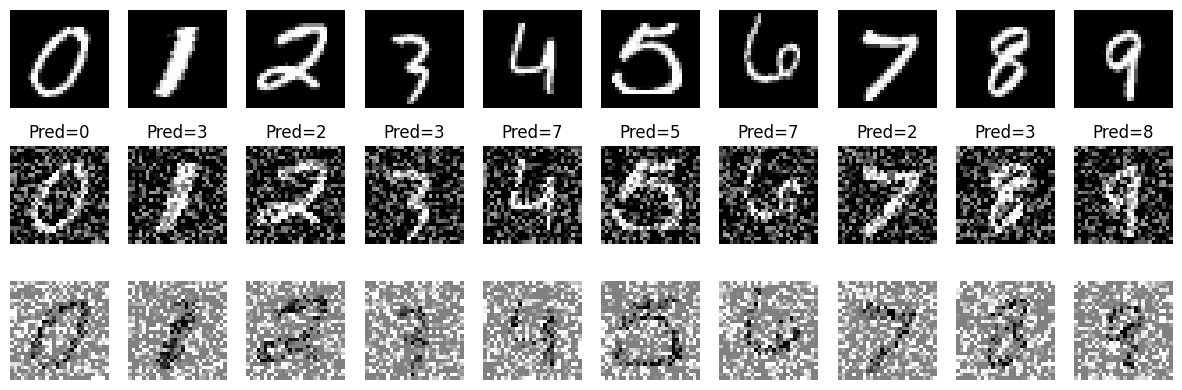

In [ ]:
fig, ax = plt.subplots(
    3,
    10,
    figsize=(15, 5),
)

for col, index in enumerate(random_sel):
    ax[0, col].imshow(
        X_test[index].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax[0, col].axis("off")

    ax[1, col].imshow(
        random_noise_result["images"][index].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax[1, col].set_title(
        f'Pred={random_noise_result["predictions"][index]}'
    )
    ax[1, col].axis("off")

    ax[2, col].imshow(
        random_noise_result["noise"][index].reshape(28, 28),
        cmap="gray",
        vmin=-0.5,
        vmax=0.5,
    )
    ax[2, col].axis("off")

plt.show()


# Gradient Information


Adversarial attacks use the gradient of the classification loss with respect to the input. The sign of this gradient identifies a direction in input space that increases the loss.


In [ ]:
loss_function = nn.CrossEntropyLoss()

X_test_gr = X_test_t.detach().clone().requires_grad_(True)

model.zero_grad()

logits = model(X_test_gr)
loss = loss_function(
    logits,
    y_test_t,
)
loss.backward()

gradient = (
    X_test_gr.grad
    .detach()
    .cpu()
    .numpy()
)

gradient_sign = np.sign(
    gradient
)

print(
    "Gradient shape:",
    gradient.shape,
)


Gradient shape: (10000, 784)


## Visualize Images, Input Gradients, and Gradient Signs


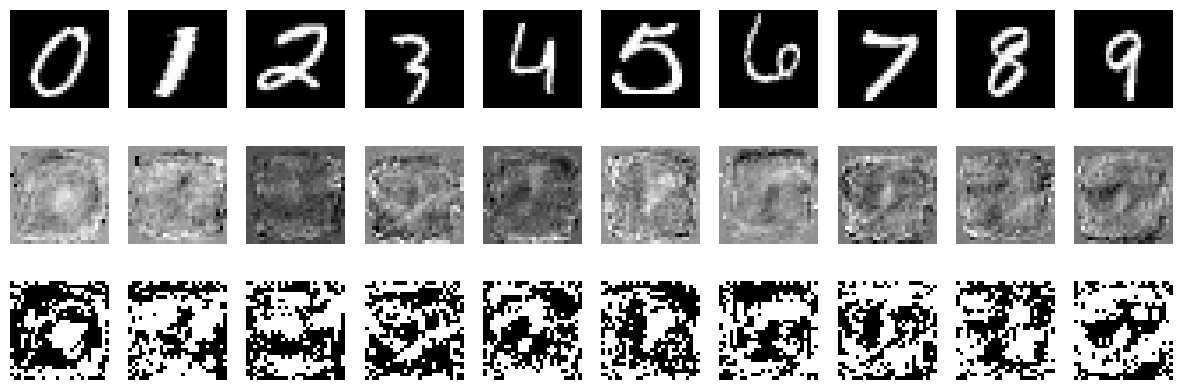

In [ ]:
fig, ax = plt.subplots(
    3,
    10,
    figsize=(15, 5),
)

for col, index in enumerate(random_sel):
    ax[0, col].imshow(
        X_test[index].reshape(28, 28),
        cmap="gray",
    )
    ax[0, col].axis("off")

    ax[1, col].imshow(
        gradient[index].reshape(28, 28),
        cmap="gray",
    )
    ax[1, col].axis("off")

    ax[2, col].imshow(
        gradient_sign[index].reshape(28, 28),
        cmap="gray",
    )
    ax[2, col].axis("off")

plt.show()


# Fast Gradient Sign Method (FGSM)


In [ ]:
def fgsm_untargeted(
    model,
    X,
    y,
    goal_accuracy=0.1,
    max_steps=200,
):
    model.eval()

    X_adv_t = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    y_t = torch.tensor(
        y,
        dtype=torch.long,
        device=device,
    )

    model.zero_grad()

    logits = model(X_adv_t)
    loss = nn.CrossEntropyLoss()(
        logits,
        y_t,
    )
    loss.backward()

    grad_sign = (
        X_adv_t.grad
        .detach()
        .sign()
        .cpu()
        .numpy()
    )

    for i in range(1, max_steps):
        epsilon = i / max_steps

        X_adv = np.clip(
            X + epsilon * grad_sign,
            0.0,
            1.0,
        )

        with torch.no_grad():
            adv_logits = model(
                torch.tensor(
                    X_adv,
                    dtype=torch.float32,
                    device=device,
                )
            )

        pred = adv_logits.argmax(
            dim=1
        ).cpu().numpy()

        accuracy = accuracy_score(
            y,
            pred,
        )

        print(
            f"epsilon={epsilon:.4f}, "
            f"accuracy={accuracy:.4f}"
        )

        if accuracy < goal_accuracy:
            break

    return {
        "epsilon": epsilon,
        "accuracy": accuracy,
        "images": X_adv,
        "noise": X_adv - X,
        "predictions": pred,
        "gradient_sign": grad_sign,
    }


fgsm_result = fgsm_untargeted(
    model,
    X_test,
    y_test,
    goal_accuracy=0.1,
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        fgsm_result["predictions"],
    )
)

print(
    "Mean absolute noise:",
    np.mean(
        np.abs(
            fgsm_result["noise"]
        )
    ),
)

print(
    "Max absolute noise:",
    np.max(
        np.abs(
            fgsm_result["noise"]
        )
    ),
)


epsilon=0.0050, accuracy=0.9718
epsilon=0.0100, accuracy=0.9588
epsilon=0.0150, accuracy=0.9372
epsilon=0.0200, accuracy=0.9076
epsilon=0.0250, accuracy=0.8649
epsilon=0.0300, accuracy=0.7973
epsilon=0.0350, accuracy=0.7143
epsilon=0.0400, accuracy=0.6210
epsilon=0.0450, accuracy=0.5331
epsilon=0.0500, accuracy=0.4487
epsilon=0.0550, accuracy=0.3754
epsilon=0.0600, accuracy=0.3105
epsilon=0.0650, accuracy=0.2579
epsilon=0.0700, accuracy=0.2150
epsilon=0.0750, accuracy=0.1789
epsilon=0.0800, accuracy=0.1504
epsilon=0.0850, accuracy=0.1293
epsilon=0.0900, accuracy=0.1108
epsilon=0.0950, accuracy=0.0997
Confusion matrix:
[[253   0 219  13   4  62 191  95  33 110]
 [  0   0  55 104   7   1   7 361 599   1]
 [ 28  80 165 320  35   2  39 204 156   3]
 [  2  13  84 151   2 368   3  43 213 131]
 [ 11   6  53  12  92   9  43 218  87 451]
 [ 16   4  14 364   5  77  44  33 264  71]
 [ 85   7 110  42 235 223 170   9  74   3]
 [  2  26 178 407  28  14   2  61  60 250]
 [ 30  10 223 397  32 121  38 

## FGSM Reconstructions and Perturbations


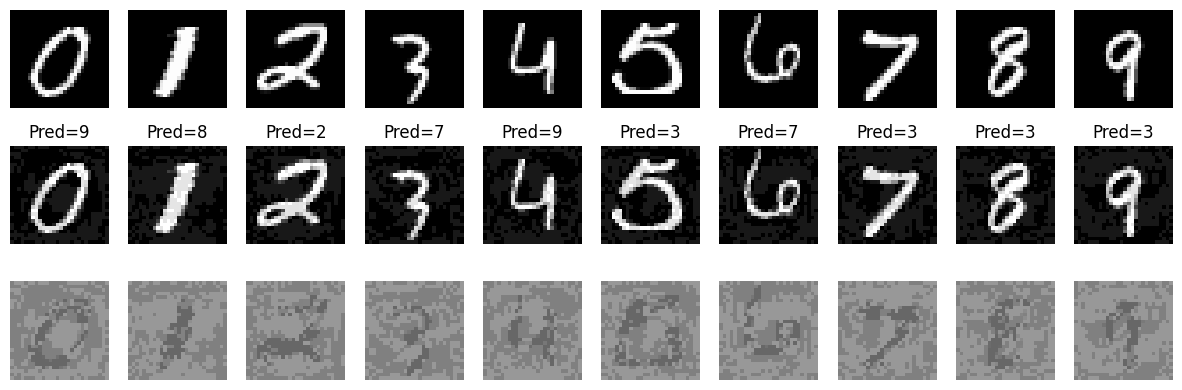

In [ ]:
fig, ax = plt.subplots(
    3,
    10,
    figsize=(15, 5),
)

for col, index in enumerate(random_sel):
    ax[0, col].imshow(
        X_test[index].reshape(28, 28),
        cmap="gray",
    )
    ax[0, col].axis("off")

    ax[1, col].imshow(
        fgsm_result["images"][index].reshape(28, 28),
        cmap="gray",
    )
    ax[1, col].set_title(
        f'Pred={fgsm_result["predictions"][index]}'
    )
    ax[1, col].axis("off")

    ax[2, col].imshow(
        fgsm_result["noise"][index].reshape(28, 28),
        cmap="gray",
        vmin=-0.5,
        vmax=0.5,
    )
    ax[2, col].axis("off")

plt.show()


## FGSM Accuracy-Threshold Variation

A second threshold is evaluated to preserve the source experiment that examines how much perturbation is needed for a less aggressive degradation target.


In [ ]:
fgsm_result_030 = fgsm_untargeted(
    model,
    X_test,
    y_test,
    goal_accuracy=0.30,
)

print(
    "FGSM epsilon for accuracy < 0.30:",
    fgsm_result_030["epsilon"],
)


epsilon=0.0050, accuracy=0.9718
epsilon=0.0100, accuracy=0.9588
epsilon=0.0150, accuracy=0.9372
epsilon=0.0200, accuracy=0.9076
epsilon=0.0250, accuracy=0.8649
epsilon=0.0300, accuracy=0.7973
epsilon=0.0350, accuracy=0.7143
epsilon=0.0400, accuracy=0.6210
epsilon=0.0450, accuracy=0.5331
epsilon=0.0500, accuracy=0.4487
epsilon=0.0550, accuracy=0.3754
epsilon=0.0600, accuracy=0.3105
epsilon=0.0650, accuracy=0.2579
FGSM epsilon for accuracy < 0.30: 0.065


# Targeted FGSM


In [ ]:
def fgsm_targeted(
    model,
    X,
    target_class,
    goal_target_rate=0.9,
    max_steps=100,
):
    model.eval()

    X_grad = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    target = torch.full(
        (len(X),),
        int(target_class),
        dtype=torch.long,
        device=device,
    )

    model.zero_grad()

    logits = model(X_grad)
    loss = nn.CrossEntropyLoss()(
        logits,
        target,
    )
    loss.backward()

    grad_sign = (
        X_grad.grad
        .detach()
        .sign()
        .cpu()
        .numpy()
    )

    for i in range(1, max_steps):
        epsilon = i / max_steps

        # Targeted FGSM moves in the direction
        # that decreases target-class loss.
        X_adv = np.clip(
            X - epsilon * grad_sign,
            0.0,
            1.0,
        )

        with torch.no_grad():
            logits_adv = model(
                torch.tensor(
                    X_adv,
                    dtype=torch.float32,
                    device=device,
                )
            )

        pred = logits_adv.argmax(
            dim=1
        ).cpu().numpy()

        target_rate = np.mean(
            pred == target_class
        )

        print(
            f"epsilon={epsilon:.4f}, "
            f"target_rate={target_rate:.4f}"
        )

        if target_rate > goal_target_rate:
            break

    return {
        "epsilon": epsilon,
        "target_rate": target_rate,
        "images": X_adv,
        "noise": X_adv - X,
        "predictions": pred,
    }


targeted_fgsm_5 = fgsm_targeted(
    model,
    X_test,
    target_class=5,
    goal_target_rate=0.90,
)

print(
    "Target-class confusion matrix:"
)
print(
    confusion_matrix(
        np.full_like(y_test, 5),
        targeted_fgsm_5["predictions"],
        labels=np.arange(10),
    )
)


epsilon=0.0100, target_rate=0.0926
epsilon=0.0200, target_rate=0.1029
epsilon=0.0300, target_rate=0.1195
epsilon=0.0400, target_rate=0.1574
epsilon=0.0500, target_rate=0.2219
epsilon=0.0600, target_rate=0.3182
epsilon=0.0700, target_rate=0.4222
epsilon=0.0800, target_rate=0.5261
epsilon=0.0900, target_rate=0.6183
epsilon=0.1000, target_rate=0.7017
epsilon=0.1100, target_rate=0.7638
epsilon=0.1200, target_rate=0.8143
epsilon=0.1300, target_rate=0.8574
epsilon=0.1400, target_rate=0.8875
epsilon=0.1500, target_rate=0.9135
Target-class confusion matrix:
[[   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [  89    0   37  137    2 9135   76    6  499   19]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    

## Target-Class Variation

The source material also explores a different target class. The same targeted FGSM implementation can therefore be evaluated for class 0.


In [ ]:
targeted_fgsm_0 = fgsm_targeted(
    model,
    X_test,
    target_class=0,
    goal_target_rate=0.50,
)

print(
    "Target rate for class 0:",
    targeted_fgsm_0["target_rate"],
)


epsilon=0.0100, target_rate=0.1008
epsilon=0.0200, target_rate=0.1030
epsilon=0.0300, target_rate=0.1082
epsilon=0.0400, target_rate=0.1183
epsilon=0.0500, target_rate=0.1327
epsilon=0.0600, target_rate=0.1588
epsilon=0.0700, target_rate=0.1943
epsilon=0.0800, target_rate=0.2380
epsilon=0.0900, target_rate=0.2871
epsilon=0.1000, target_rate=0.3397
epsilon=0.1100, target_rate=0.3938
epsilon=0.1200, target_rate=0.4480
epsilon=0.1300, target_rate=0.4990
epsilon=0.1400, target_rate=0.5366
Target rate for class 0: 0.5366


# Basic Iterative Method (BIM)


In [ ]:
def bim_untargeted(
    model,
    X,
    y,
    step_size=0.01,
    goal_accuracy=0.1,
    max_steps=200,
):
    model.eval()

    X_adv = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    y_t = torch.tensor(
        y,
        dtype=torch.long,
        device=device,
    )

    for iteration in range(max_steps):
        logits = model(X_adv)

        pred = logits.argmax(
            dim=1
        ).detach().cpu().numpy()

        accuracy = accuracy_score(
            y,
            pred,
        )

        print(
            f"iteration={iteration:3d}, "
            f"accuracy={accuracy:.4f}"
        )

        if accuracy < goal_accuracy:
            break

        loss = nn.CrossEntropyLoss()(
            logits,
            y_t,
        )

        model.zero_grad()

        if X_adv.grad is not None:
            X_adv.grad.zero_()

        loss.backward()

        with torch.no_grad():
            X_adv += (
                step_size
                * X_adv.grad.sign()
            )
            X_adv.clamp_(0.0, 1.0)

    X_adv_np = (
        X_adv.detach()
        .cpu()
        .numpy()
    )

    return {
        "iterations": iteration,
        "accuracy": accuracy,
        "images": X_adv_np,
        "noise": X_adv_np - X,
        "predictions": pred,
    }


bim_result = bim_untargeted(
    model,
    X_test,
    y_test,
    step_size=0.01,
    goal_accuracy=0.10,
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        bim_result["predictions"],
    )
)


iteration=  0, accuracy=0.9807
iteration=  1, accuracy=0.9588
iteration=  2, accuracy=0.9063
iteration=  3, accuracy=0.7887
iteration=  4, accuracy=0.6010
iteration=  5, accuracy=0.4236
iteration=  6, accuracy=0.2810
iteration=  7, accuracy=0.1813
iteration=  8, accuracy=0.1103
iteration=  9, accuracy=0.0650
Confusion matrix:
[[230   0 226  12   4  70 184 111  33 110]
 [  0   0  63 109   7   1  10 370 574   1]
 [ 28  77 122 343  35   3  45 212 164   3]
 [  2  12  91  91   2 403   4  45 217 143]
 [ 11   7  54  11  13  10  48 247  89 492]
 [ 17   4  17 394   5  31  48  34 271  71]
 [ 81   8 125  49 241 223 127  11  89   4]
 [  4  23 194 428  32  18   1  22  60 246]
 [ 31  10 226 397  33 122  40  29  13  73]
 [  7  10   9 120 363  57   5 323 114   1]]


# Targeted Basic Iterative Method


In [ ]:
def bim_targeted(
    model,
    X,
    target_class,
    step_size=0.005,
    goal_target_rate=0.90,
    max_steps=200,
):
    model.eval()

    X_adv = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    target = torch.full(
        (len(X),),
        int(target_class),
        dtype=torch.long,
        device=device,
    )

    for iteration in range(max_steps):
        logits = model(X_adv)

        pred = logits.argmax(
            dim=1
        ).detach().cpu().numpy()

        target_rate = np.mean(
            pred == target_class
        )

        print(
            f"iteration={iteration:3d}, "
            f"target_rate={target_rate:.4f}"
        )

        if target_rate > goal_target_rate:
            break

        loss = nn.CrossEntropyLoss()(
            logits,
            target,
        )

        model.zero_grad()

        if X_adv.grad is not None:
            X_adv.grad.zero_()

        loss.backward()

        with torch.no_grad():
            X_adv -= (
                step_size
                * X_adv.grad.sign()
            )
            X_adv.clamp_(0.0, 1.0)

    X_adv_np = (
        X_adv.detach()
        .cpu()
        .numpy()
    )

    return {
        "iterations": iteration,
        "target_rate": target_rate,
        "images": X_adv_np,
        "noise": X_adv_np - X,
        "predictions": pred,
    }


bim_target_5 = bim_targeted(
    model,
    X_test,
    target_class=5,
    step_size=0.005,
    goal_target_rate=0.90,
)

print(
    "Target-class confusion matrix:"
)
print(
    confusion_matrix(
        np.full_like(y_test, 5),
        bim_target_5["predictions"],
        labels=np.arange(10),
    )
)


iteration=  0, target_rate=0.0881
iteration=  1, target_rate=0.0903
iteration=  2, target_rate=0.0925
iteration=  3, target_rate=0.0973
iteration=  4, target_rate=0.1032
iteration=  5, target_rate=0.1117
iteration=  6, target_rate=0.1222
iteration=  7, target_rate=0.1400
iteration=  8, target_rate=0.1662
iteration=  9, target_rate=0.2005
iteration= 10, target_rate=0.2504
iteration= 11, target_rate=0.3064
iteration= 12, target_rate=0.3744
iteration= 13, target_rate=0.4492
iteration= 14, target_rate=0.5175
iteration= 15, target_rate=0.5831
iteration= 16, target_rate=0.6452
iteration= 17, target_rate=0.7024
iteration= 18, target_rate=0.7511
iteration= 19, target_rate=0.7955
iteration= 20, target_rate=0.8305
iteration= 21, target_rate=0.8608
iteration= 22, target_rate=0.8882
iteration= 23, target_rate=0.9076
Target-class confusion matrix:
[[   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0 

## Additional BIM Target-Class Experiment

A second target, class 8, is retained as a distinct parameter experiment.


In [ ]:
bim_target_8 = bim_targeted(
    model,
    X_test,
    target_class=8,
    step_size=0.005,
    goal_target_rate=0.95,
)

print(
    "Target rate for class 8:",
    bim_target_8["target_rate"],
)


iteration=  0, target_rate=0.0975
iteration=  1, target_rate=0.0997
iteration=  2, target_rate=0.1043
iteration=  3, target_rate=0.1110
iteration=  4, target_rate=0.1186
iteration=  5, target_rate=0.1347
iteration=  6, target_rate=0.1659
iteration=  7, target_rate=0.2170
iteration=  8, target_rate=0.2774
iteration=  9, target_rate=0.3400
iteration= 10, target_rate=0.3987
iteration= 11, target_rate=0.4581
iteration= 12, target_rate=0.5164
iteration= 13, target_rate=0.5739
iteration= 14, target_rate=0.6289
iteration= 15, target_rate=0.6798
iteration= 16, target_rate=0.7262
iteration= 17, target_rate=0.7670
iteration= 18, target_rate=0.8027
iteration= 19, target_rate=0.8356
iteration= 20, target_rate=0.8638
iteration= 21, target_rate=0.8854
iteration= 22, target_rate=0.9081
iteration= 23, target_rate=0.9269
iteration= 24, target_rate=0.9395
iteration= 25, target_rate=0.9512
Target rate for class 8: 0.9512


## Attack Comparison

The random-noise baseline perturbs pixels without using model information. FGSM uses a single gradient direction, while BIM recomputes the gradient after each update. Targeted versions reverse the optimization objective so predictions move toward a chosen class.

The experiments make it possible to compare attack strength in terms of accuracy degradation, target success rate, and perturbation magnitude.
